# GRL Miniproject: Oversmoothing vs. Over-Squashing

**Research Question:** 

Do residual (skip) connections and graph rewiring complement each other in addressing the oversmoothing/over-squashing trade-off, or does fixing one failure mode worsen the other?

**2×2 experiment grid:**

| | Original graph | Rewired graph (SDRF) |
|---|---|-->>-|
| **GCN** | Baseline | Rewiring only |
| **SkipGCN** | Skip only | Skip + Rewiring |

Measured on:
- **Graph A** (oversmoothing): Stochastic Block Model - dense communities, label = community index
- **Graph B** (over-squashing): Barbell graph - two dense clusters joined by a bridge path, label = clique membership

## 0. Setup and main configurations

In [ ]:
# Install dependencies
# !pip install -r requirements.txt

In [ ]:
import sys
sys.path.insert(0, 'src')

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

from torch_geometric.data import Data
from torch_geometric.utils import to_networkx

from models import GCN, SkipGCN
from graphs import make_sbm_graph, make_barbell_graph, make_barbell_dataset, split_dataset, train_val_test_split
from rewiring import sdrf_rewire, sdrf_rewire_batch, curvature_stats, compute_ricci_curvature
from metrics import mean_average_distance, dirichlet_energy, sensitivity_vs_distance
from training import train_model, evaluate, train_graph_model, evaluate_graph_model


DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SEED    = 42
HID_DIM = 64
LAYERS  = [2, 4, 8, 16]
TRAIN_PARAMS = dict(lr=0.01, weight_decay=5e-4, epochs=300, patience=20, device=DEVICE)

COLORS = {
    'GCN': '#4878CF', 'SkipGCN': '#D65F5F',
    'GCN+Rewire': '#6ACC65', 'Skip+Rewire': '#B47CC7',
}
LINESTYLES = {'GCN': '-', 'SkipGCN': '--', 'GCN+Rewire': '-.', 'Skip+Rewire': ':'}

torch.manual_seed(SEED)
np.random.seed(SEED)
print(f'Device: {DEVICE}')

Device: cpu


## 1. Graph Construction

- **SBM**: 4 communities × 50 nodes, high intra-community density -> triggers oversmoothing
- **Barbell**: two cliques (5 nodes each) joined by a bridge path of length 3 -> clear topological bottleneck for over-squashing. This is the *same* topology used throughout Experiments B and C; here we build one representative instance for curvature statistics and visualization.

In [ ]:
# Graph A: SBM - for demonstrating oversmoothing
data_sbm = train_val_test_split(
    make_sbm_graph(n_communities=4, nodes_per_community=50,
                   p_intra=0.7, p_inter=0.02, feature_dim=16, seed=SEED),
    seed=SEED)
print('SBM:', data_sbm)

# Graph B: Barbell - for demonstrating over-squashing.
data_barbell = make_barbell_graph(clique_size=5, bridge_length=3, feature_dim=4, seed=SEED)
print('Barbell (clique=5, bridge=3):', data_barbell)

SBM: Data(edge_index=[2, 7536], block=[200], partition=[4], name='stochastic_block_model', num_nodes=200, x=[200, 16], y=[200], num_classes=4, train_mask=[200], val_mask=[200], test_mask=[200])
Barbell (clique=5, bridge=3): Data(edge_index=[2, 46], num_nodes=12, x=[12, 4], y=[12], num_classes=2, clique_size=5, bridge_length=3)


## 2. Graph Rewiring (SDRF)

SDRF iteratively adds edges at the most negatively curved (bottleneck) locations.
We use **α=0** (pure neighbor mass) so that edges with no shared triangle structure get negative curvature - this correctly identifies topological bottlenecks.

In [15]:
# Curvature stats before rewiring
print('Curvature stats (original graphs):')
for name, g in [('SBM', data_sbm), ('Barbell', data_barbell)]:
    s = curvature_stats(g)
    print(f'  {name:8s}  mean κ={s["mean"]:+.3f}  min κ={s["min"]:+.3f}  '
          f'n_negative={s["n_negative"]}/{s["n_edges"]}')

Curvature stats (original graphs):
  SBM       mean κ=+0.486  min κ=-0.719  n_negative=612/3768
  Barbell   mean κ=+0.548  min κ=-0.600  n_negative=4/23


In [4]:
print('Rewiring SBM...')
data_sbm_rew = sdrf_rewire(data_sbm, n_iterations=30, tau=0.0)
print(f'  SBM edges:     {data_sbm.edge_index.size(1)//2} -> {data_sbm_rew.edge_index.size(1)//2}')

print('Rewiring Barbell...')
data_barbell_rew = sdrf_rewire(data_barbell, n_iterations=20, tau=0.0)
print(f'  Barbell edges: {data_barbell.edge_index.size(1)//2} -> {data_barbell_rew.edge_index.size(1)//2}')

Rewiring SBM...
  SBM edges:     3768 -> 3798
Rewiring Barbell...
  Barbell edges: 23 -> 35


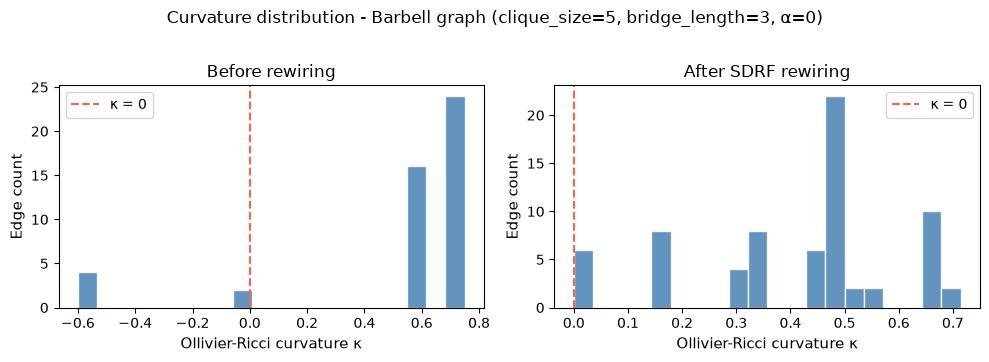

In [ ]:
# Curvature distribution of the barbell (clique_size=5, bridge_length=3) before vs after rewiring.
curv_before = list(compute_ricci_curvature(data_barbell).values())
curv_after  = list(compute_ricci_curvature(data_barbell_rew).values())

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=False)
for ax, vals, title in zip(axes,
                            [curv_before, curv_after],
                            ["Before rewiring", "After SDRF rewiring"]):
    ax.hist(vals, bins=20, color="steelblue", edgecolor="white", alpha=0.85)
    ax.axvline(0, color="tomato", lw=1.5, linestyle="--", label="κ = 0")
    ax.set_xlabel("Ollivier-Ricci curvature κ", fontsize=11)
    ax.set_ylabel("Edge count", fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=10)
plt.suptitle("Curvature distribution - Barbell graph (clique_size=5, bridge_length=3, α=0)",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("curvature_distributions.pdf", bbox_inches="tight")
plt.show()

### Barbell topology - before and after rewiring

The signal-propagation task plants a binary signal at the **source** (node 0, left clique) and reads it out only at the **target** (node `clique_size`, right clique). In the original graph these are separated by a long, thin bridge - the over-squashing bottleneck. SDRF adds shortcut edges (green) concentrated at the most negatively curved bridge endpoints, collapsing the bottleneck.

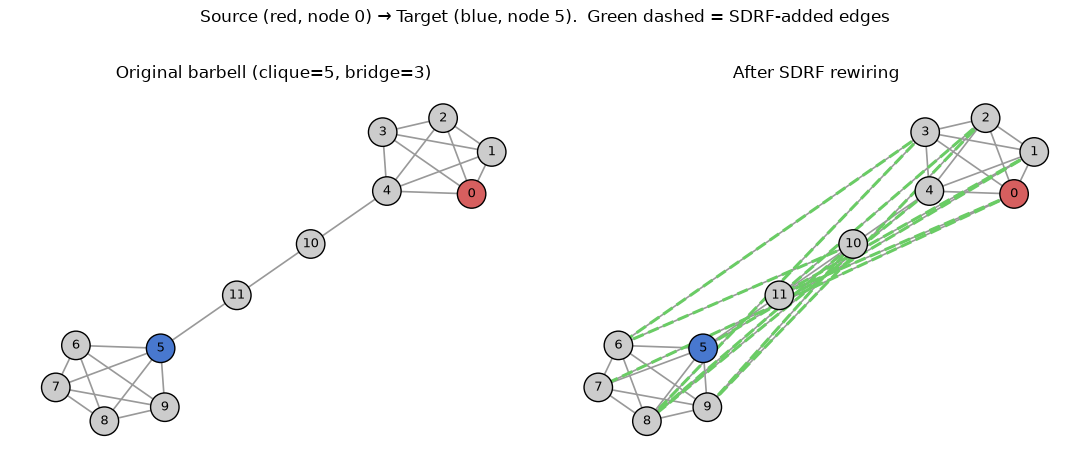

In [ ]:
src_node = 0
tgt_node = int(data_barbell.clique_size)   # first node of the right clique

G_orig = to_networkx(data_barbell,     to_undirected=True)
G_rew  = to_networkx(data_barbell_rew, to_undirected=True)
pos    = nx.kamada_kawai_layout(G_orig)

def _node_colors(G):
    out = []
    for n in G.nodes():
        if   n == src_node: out.append('#D65F5F')   # source = red
        elif n == tgt_node: out.append('#4878CF')   # target = blue
        else:               out.append('#cccccc')
    return out

orig_edge_set = set(map(frozenset, G_orig.edges()))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, G, title in [(axes[0], G_orig, 'Original barbell (clique=5, bridge=3)'),
                     (axes[1], G_rew,  'After SDRF rewiring')]:
    added = [e for e in G.edges() if frozenset(e) not in orig_edge_set]
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color='#999999', width=1.2)
    if added:
        nx.draw_networkx_edges(G, pos, edgelist=added, ax=ax,
                               edge_color='#6ACC65', width=2.2, style='dashed')
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=_node_colors(G),
                           node_size=420, edgecolors='black')
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=9)
    ax.set_title(title, fontsize=12); ax.axis('off')

plt.suptitle('Source (red, node 0) -> Target (blue, node 5).  '
             'Green dashed = SDRF-added edges', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('barbell_topology.pdf', bbox_inches='tight')
plt.show()

## 3. Experiment A: Oversmoothing on SBM Graph

Sweep depth K ∈ {2, 4, 8, 16} for all 4 conditions.

**Metrics:**
- **MAD** (Mean Average Distance): cosine distance between all node embedding pairs. High = distinguishable = not oversmoothed.
- **Dirichlet Energy**: mean squared difference across edges. Collapses to 0 under oversmoothing.
- **Test Accuracy**: downstream classification performance.

In [7]:
conditions_sbm = {
    'GCN':         (GCN,     data_sbm),
    'SkipGCN':     (SkipGCN, data_sbm),
    'GCN+Rewire':  (GCN,     data_sbm_rew),
    'Skip+Rewire': (SkipGCN, data_sbm_rew),
}
in_dim_sbm = data_sbm.x.size(1)
n_cls_sbm  = data_sbm.num_classes

results_mad     = {n: [] for n in conditions_sbm}
results_de      = {n: [] for n in conditions_sbm}
results_acc_sbm = {n: [] for n in conditions_sbm}

for K in LAYERS:
    print(f'\nK={K}')
    for name, (Cls, graph) in conditions_sbm.items():
        torch.manual_seed(SEED)
        model = Cls(in_dim_sbm, HID_DIM, n_cls_sbm, K)
        model, _, _ = train_model(model, graph, **TRAIN_PARAMS)
        emb = model.embed(graph.x.to(DEVICE), graph.edge_index.to(DEVICE)).cpu()
        mad = mean_average_distance(emb)
        de  = dirichlet_energy(emb, graph.edge_index)
        acc = evaluate(model, graph, graph.test_mask, DEVICE)
        results_mad[name].append(mad)
        results_de[name].append(de)
        results_acc_sbm[name].append(acc)
        print(f'  {name:15s}  MAD={mad:.4f}  DE={de:.4f}  Acc={acc:.3f}')


K=2
  GCN              MAD=0.3023  DE=0.0220  Acc=1.000
  SkipGCN          MAD=0.7431  DE=53.0945  Acc=0.950
  GCN+Rewire       MAD=0.2959  DE=0.0231  Acc=1.000
  Skip+Rewire      MAD=0.7440  DE=53.2358  Acc=0.950

K=4
  GCN              MAD=0.2589  DE=0.0602  Acc=1.000
  SkipGCN          MAD=0.5315  DE=49.4397  Acc=0.975
  GCN+Rewire       MAD=0.2734  DE=0.0575  Acc=1.000
  Skip+Rewire      MAD=0.5341  DE=49.8545  Acc=0.975

K=8
  GCN              MAD=0.3547  DE=66.6155  Acc=0.375
  SkipGCN          MAD=0.3952  DE=51.4545  Acc=1.000
  GCN+Rewire       MAD=0.2415  DE=13.2400  Acc=0.300
  Skip+Rewire      MAD=0.3952  DE=51.0824  Acc=1.000

K=16
  GCN              MAD=0.0001  DE=0.0007  Acc=0.150
  SkipGCN          MAD=0.4333  DE=1531.9404  Acc=1.000
  GCN+Rewire       MAD=0.0001  DE=0.0001  Acc=0.225
  Skip+Rewire      MAD=0.4036  DE=549.2250  Acc=1.000


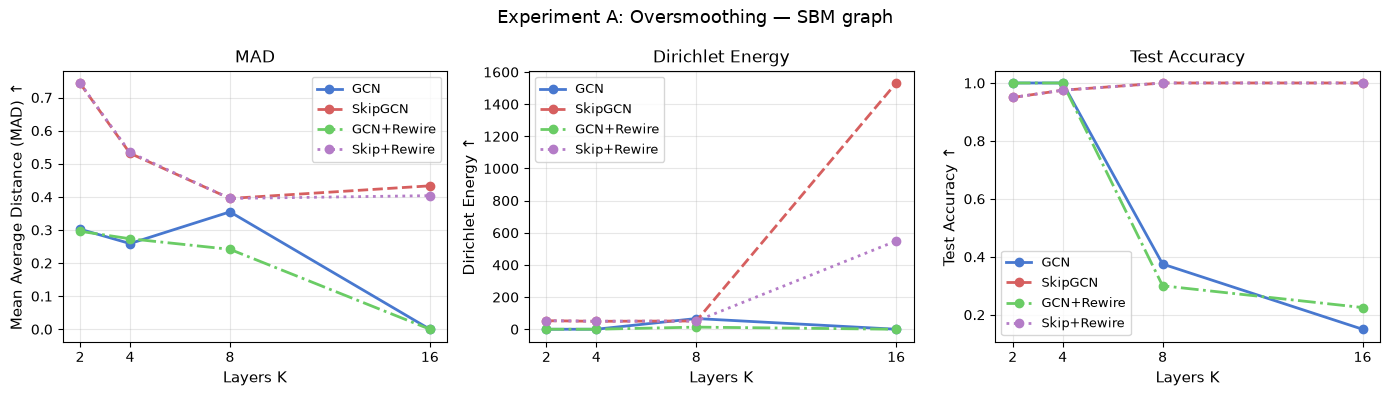

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (d, ylabel, title) in zip(axes, [
    (results_mad,     'Mean Average Distance (MAD)', 'MAD'),
    (results_de,      'Dirichlet Energy',             'Dirichlet Energy'),
    (results_acc_sbm, 'Test Accuracy',                'Test Accuracy'),
]):
    for name, vals in d.items():
        ax.plot(LAYERS, vals, marker='o', label=name,
                color=COLORS[name], linestyle=LINESTYLES[name], lw=2)
    ax.set_xlabel('Layers K', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.set_xticks(LAYERS)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Experiment A: Oversmoothing - SBM graph', fontsize=13)
plt.tight_layout()
plt.savefig('exp_a_oversmoothing.pdf', bbox_inches='tight')
plt.show()

## 4. Experiment B: Over-Squashing - Source-to-Target Signal Propagation

We generate a dataset of **barbell graphs** (two cliques connected by a bridge path).
Each graph has a binary signal planted at **source node 0** (left clique).
The model must predict this signal using ONLY the **target node** (first node of right clique).

Distance source > target =  hops (node 0 is 1 hop from the bridge
entry within the dense left clique, then  more hops across the bridge).

This is a genuine long-range task: information **must** cross the bridge;
it cannot be shortcut by global pooling or local features.

### B.1 - Vary depth K (fixed bridge_length=3, distance=4 hops)

In [ ]:
BRIDGE_FIXED = 3   # source-to-target distance = 1 + 3 = 4 hops
CLIQUE_SIZE  = 5
FEAT_DIM_BB  = 4
N_GRAPHS     = 400
TRAIN_PARAMS_BB = dict(lr=0.005, weight_decay=1e-4, epochs=300, patience=30, batch_size=32, device=DEVICE)

graphs_fixed = make_barbell_dataset(N_GRAPHS, CLIQUE_SIZE, BRIDGE_FIXED, FEAT_DIM_BB, SEED)
train_g, val_g, test_g = split_dataset(graphs_fixed, seed=SEED)
print(f"{len(train_g)} train / {len(val_g)} val / {len(test_g)} test graphs")
print(f"Source-to-target distance: 1 + {BRIDGE_FIXED} = {1+BRIDGE_FIXED} hops")

results_acc_bb = {n: [] for n in ["GCN","SkipGCN"]}

for K in LAYERS:
    print(f"K={K}")
    for name, Cls in [("GCN", GCN), ("SkipGCN", SkipGCN)]:
        torch.manual_seed(SEED)
        model = Cls(FEAT_DIM_BB, HID_DIM, 2, K)
        model, _, _ = train_graph_model(model, train_g, val_g, **TRAIN_PARAMS_BB)
        acc = evaluate_graph_model(model, test_g, device=DEVICE)
        results_acc_bb[name].append(acc)
        print(f"  {name:10s}  Acc={acc:.3f}")

240 train / 80 val / 80 test graphs
Source-to-target distance: 1 + 3 = 4 hops
K=2
  GCN         Acc=0.463
  SkipGCN     Acc=0.425
K=4
  GCN         Acc=1.000
  SkipGCN     Acc=1.000
K=8
  GCN         Acc=0.463
  SkipGCN     Acc=1.000
K=16
  GCN         Acc=0.537
  SkipGCN     Acc=1.000


### B.2 - Vary bridge length (fixed K=8)

Longer bridge = longer required range AND stronger bottleneck.
We also apply SDRF rewiring per bridge length and compare all four conditions.

In [ ]:
BRIDGE_LENGTHS = [1, 2, 3, 4, 5, 7]
FIXED_K = 8
results_acc_bridge = {n: [] for n in ["GCN","SkipGCN","GCN+Rewire","Skip+Rewire"]}

# --- Topology reuse + batch rewiring ---
# All barbell instances with the same bridge_length share identical topology.
# Build one template per bridge length, rewire all 6 in a SINGLE subprocess call
# (pays GraphRicciCurvature import overhead once instead of once per graph).
print("Pre-computing datasets and rewiring all bridge lengths in one subprocess call...")
templates = [make_barbell_dataset(1, CLIQUE_SIZE, bl, FEAT_DIM_BB, SEED)[0]
             for bl in BRIDGE_LENGTHS]
rewired_templates = sdrf_rewire_batch(templates, n_iterations=20, tau=0.0)
rewired_edge_indexes = [rt.edge_index for rt in rewired_templates]
print("Rewiring done.")
for bl, tmpl, rt in zip(BRIDGE_LENGTHS, templates, rewired_templates):
    n_orig = tmpl.edge_index.size(1) // 2
    n_rew  = rt.edge_index.size(1) // 2
    print(f"  bridge_length={bl}: {n_orig} -> {n_rew} edges")

for bl, rew_ei in zip(BRIDGE_LENGTHS, rewired_edge_indexes):
    print(f"\nbridge_length={bl}  (distance={1+bl} hops)")
    graphs_bl = make_barbell_dataset(N_GRAPHS, CLIQUE_SIZE, bl, FEAT_DIM_BB, SEED)
    # Reuse rewired topology - create rewired copies sharing the same edge_index
    graphs_bl_rew = [
        Data(x=g.x, edge_index=rew_ei, y=g.y,
             num_nodes=g.num_nodes, target_node=g.target_node)
        for g in graphs_bl
    ]
    train_bl,  val_bl,  test_bl  = split_dataset(graphs_bl,     seed=SEED)
    train_blr, val_blr, test_blr = split_dataset(graphs_bl_rew, seed=SEED)
    for name, (tr, vl, te) in [
        ("GCN",         (train_bl,  val_bl,  test_bl)),
        ("SkipGCN",     (train_bl,  val_bl,  test_bl)),
        ("GCN+Rewire",  (train_blr, val_blr, test_blr)),
        ("Skip+Rewire", (train_blr, val_blr, test_blr)),
    ]:
        Cls = SkipGCN if "Skip" in name else GCN
        torch.manual_seed(SEED)
        model = Cls(FEAT_DIM_BB, HID_DIM, 2, FIXED_K)
        model, _, _ = train_graph_model(model, tr, vl, **TRAIN_PARAMS_BB)
        acc = evaluate_graph_model(model, te, device=DEVICE)
        results_acc_bridge[name].append(acc)
        print(f"  {name:15s}  Acc={acc:.3f}")

Pre-computing datasets and rewiring all bridge lengths in one subprocess call...
Rewiring done.
  bridge_length=1: 21 -> 24 edges
  bridge_length=2: 22 -> 30 edges
  bridge_length=3: 23 -> 35 edges
  bridge_length=4: 24 -> 36 edges
  bridge_length=5: 25 -> 40 edges
  bridge_length=7: 27 -> 47 edges

bridge_length=1  (distance=2 hops)
  GCN              Acc=1.000
  SkipGCN          Acc=1.000
  GCN+Rewire       Acc=1.000
  Skip+Rewire      Acc=1.000

bridge_length=2  (distance=3 hops)
  GCN              Acc=1.000
  SkipGCN          Acc=1.000
  GCN+Rewire       Acc=1.000
  Skip+Rewire      Acc=1.000

bridge_length=3  (distance=4 hops)
  GCN              Acc=0.463
  SkipGCN          Acc=1.000
  GCN+Rewire       Acc=1.000
  Skip+Rewire      Acc=1.000

bridge_length=4  (distance=5 hops)
  GCN              Acc=0.537
  SkipGCN          Acc=1.000
  GCN+Rewire       Acc=0.988
  Skip+Rewire      Acc=1.000

bridge_length=5  (distance=6 hops)
  GCN              Acc=0.500
  SkipGCN          Acc=0.50

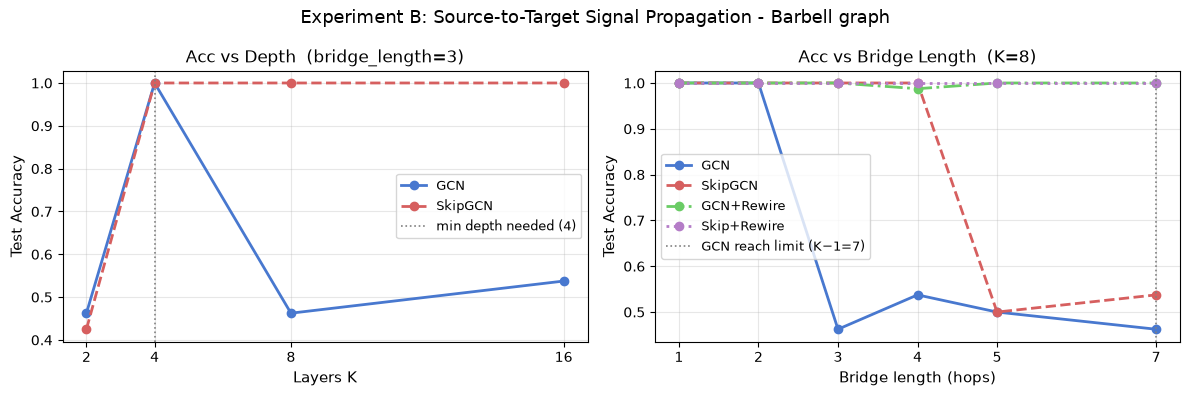

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
for name, vals in results_acc_bb.items():
    ax.plot(LAYERS, vals, marker="o", label=name,
            color=COLORS[name], linestyle=LINESTYLES[name], lw=2)
ax.axvline(1 + BRIDGE_FIXED, color="gray", lw=1.2, linestyle=":",
           label=f"min depth needed ({1+BRIDGE_FIXED})")
ax.set_xlabel("Layers K", fontsize=11)
ax.set_ylabel("Test Accuracy", fontsize=11)
ax.set_title(f"Acc vs Depth  (bridge_length={BRIDGE_FIXED})", fontsize=12)
ax.set_xticks(LAYERS); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1]
for name, vals in results_acc_bridge.items():
    ax.plot(BRIDGE_LENGTHS, vals, marker="o", label=name,
            color=COLORS[name], linestyle=LINESTYLES[name], lw=2)
# Plain GCN can only reach ~K-1 hops; rewiring breaks this depth=reach assumption
# by shortening the effective bridge, so the rewired conditions succeed past it.
ax.axvline(FIXED_K - 1, color="gray", lw=1.2, linestyle=":",
           label=f"GCN reach limit (K−1={FIXED_K-1})")
ax.set_xlabel("Bridge length (hops)", fontsize=11)
ax.set_ylabel("Test Accuracy", fontsize=11)
ax.set_title(f"Acc vs Bridge Length  (K={FIXED_K})", fontsize=12)
ax.set_xticks(BRIDGE_LENGTHS); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.suptitle("Experiment B: Source-to-Target Signal Propagation - Barbell graph", fontsize=13)
plt.tight_layout()
plt.savefig("exp_b_oversquashing.pdf", bbox_inches="tight")
plt.show()

## 5. Experiment C: Jacobian Sensitivity vs Distance

We compute the Jacobian norm ||∂h_v^(K) / ∂x_u|| for pairs (u, v) at varying graph distances. This measures how much influence node u's initial features have on node v's final representation - the canonical measure of over-squashing. Exponential decay = severe over-squashing.

**Reading the plot:** the two rewired conditions (`GCN+Rewire`, `Skip+Rewire`) only have points at distances 1–2. This is *not* missing data - SDRF adds shortcut edges that collapse the graph diameter, so after rewiring no node pairs remain at distance ≥ 3. The truncated curves are themselves direct evidence that rewiring reduces over-squashing by shortening the longest paths the signal must travel.

In [ ]:

JACOBIAN_K = 8
jacobian_results = {}

# Use the fixed barbell dataset graphs (bridge_length=3).
# All instances share the same topology - rewire once and reuse the edge_index.
jac_graphs_orig = graphs_fixed
jac_rew_template = sdrf_rewire(jac_graphs_orig[0], n_iterations=20, tau=0.0)
rew_ei = jac_rew_template.edge_index
jac_graphs_rew = [
    Data(x=g.x, edge_index=rew_ei, y=g.y,
         num_nodes=g.num_nodes, target_node=g.target_node)
    for g in jac_graphs_orig
]

for name, graph_list in [
    ("GCN",         jac_graphs_orig),
    ("SkipGCN",     jac_graphs_orig),
    ("GCN+Rewire",  jac_graphs_rew),
    ("Skip+Rewire", jac_graphs_rew),
]:
    Cls = SkipGCN if "Skip" in name else GCN
    torch.manual_seed(SEED)
    model = Cls(FEAT_DIM_BB, HID_DIM, 2, JACOBIAN_K)
    model, _, _ = train_graph_model(model, *split_dataset(graph_list, seed=SEED)[:2],
                                    **TRAIN_PARAMS_BB)
    # pick one representative graph for Jacobian analysis
    sens = sensitivity_vs_distance(model, graph_list[0], n_pairs=30,
                                   max_distance=10, device=DEVICE)
    jacobian_results[name] = sens
    print(f"{name}: {sens}")

GCN: {1: 0.0007510980144919206, 2: 0.00045156317646615206, 3: 0.00017205808593037848, 4: 0.00011557085235835984, 5: 3.1493954702455083e-05}
SkipGCN: {1: 12.291469003756841, 2: 1.5703202242652574, 3: 0.5467083881298701, 4: 0.18472467102110385, 5: 0.011425674213872602}
GCN+Rewire: {1: 0.01672709467820823, 2: 0.026426190386215846}
Skip+Rewire: {1: 1.4953465481599173, 2: 0.4529564753174782}


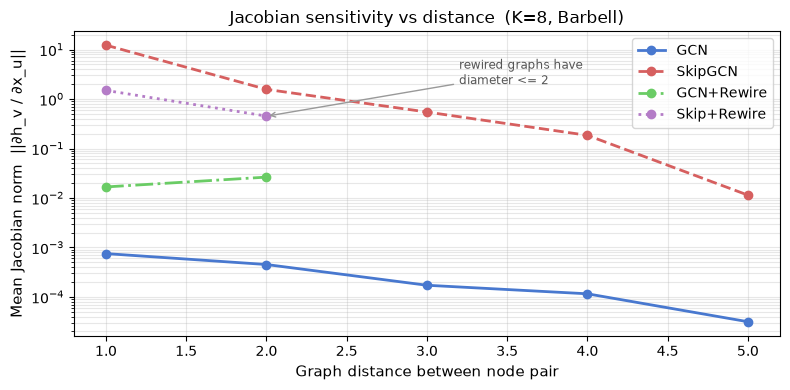

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
for name, sens_dict in jacobian_results.items():
    dists = sorted(sens_dict.keys())
    vals  = [sens_dict[d] for d in dists]
    ax.plot(dists, vals, marker='o', label=name,
            color=COLORS[name], linestyle=LINESTYLES[name], lw=2)

ax.set_xlabel('Graph distance between node pair', fontsize=11)
ax.set_ylabel('Mean Jacobian norm  ||∂h_v / ∂x_u||', fontsize=11)
ax.set_title(f'Jacobian sensitivity vs distance  (K={JACOBIAN_K}, Barbell)', fontsize=12)
ax.set_yscale('log')

# Note: rewired curves stop at distance 2 because SDRF shrinks the graph diameter
# (no node pairs remain at distance >= 3) - itself evidence of reduced over-squashing.
ax.annotate('rewired graphs have\ndiameter <= 2', xy=(2, 0.45),
            xytext=(3.2, 2.0), fontsize=8.5, color='#555555',
            arrowprops=dict(arrowstyle='->', color='#999999', lw=1))

ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.savefig('exp_c_jacobian.pdf', bbox_inches='tight')
plt.show()

## 6. Summary Table

In [ ]:

K_IDX  = LAYERS.index(8)
BL_IDX = BRIDGE_LENGTHS.index(3)

rows = []
for name in ["GCN", "SkipGCN", "GCN+Rewire", "Skip+Rewire"]:
    rows.append({
        "Model":                   name,
        "MAD (SBM)":             f"{results_mad[name][K_IDX]:.4f}",
        "Acc (SBM)":             f"{results_acc_sbm[name][K_IDX]:.3f}",
        "Acc (Barbell bl=3, K=8)": f"{results_acc_bridge[name][BL_IDX]:.3f}",
    })

df = pd.DataFrame(rows).set_index("Model")
print(df.to_string())
df

            MAD (SBM) ↑ Acc (SBM) ↑ Acc (Barbell bl=3, K=8) ↑
Model                                                        
GCN              0.3547       0.375                     0.463
SkipGCN          0.3952       1.000                     1.000
GCN+Rewire       0.2415       0.300                     1.000
Skip+Rewire      0.3952       1.000                     1.000


,MAD (SBM) ↑,Acc (SBM) ↑,"Acc (Barbell bl=3, K=8) ↑"
Model,,,
GCN,0.3547,0.375,0.463
SkipGCN,0.3952,1.000,1.000
GCN+Rewire,0.2415,0.300,1.000
Skip+Rewire,0.3952,1.000,1.000
